In [1]:
!pip install pymupdf
!pip install sentence-transformers
!pip install scikit-learn
!pip install nltk
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 20.2 MB/s eta 0:00:00


In [2]:
import fitz
import pandas as pd
import nltk
import re

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

nltk.download('stopwords')

from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [17]:
from google.colab import files

uploaded = files.upload()

Saving HARSHAJEET SURESH PATIL DADS.pdf to HARSHAJEET SURESH PATIL DADS (1).pdf
Saving KAMINI.pdf to KAMINI.pdf
Saving Mr. ROHIT ROHIDAS MHATRE RESUME LATEST UPDATED (1)[1] (2).pdf to Mr. ROHIT ROHIDAS MHATRE RESUME LATEST UPDATED (1)[1] (2).pdf
Saving Sushil Ambekar resume.pdf to Sushil Ambekar resume.pdf
Saving SWAPNIL_GILBILE_DADS.pdf to SWAPNIL_GILBILE_DADS.pdf
Saving Vaibhavi CV.pdf to Vaibhavi CV.pdf


In [18]:
def extract_text_from_pdf(pdf_path):

    text = ""

    doc = fitz.open(pdf_path)

    for page in doc:
        text += page.get_text()

    return text

In [19]:
resume_texts = {}

for file_name in uploaded.keys():

    text = extract_text_from_pdf(file_name)

    resume_texts[file_name] = text

In [20]:
for name, text in resume_texts.items():

    print("RESUME:", name)

    print(text[:1000])

    print("\n")

RESUME: HARSHAJEET SURESH PATIL DADS (1).pdf
HARSHAJEET SURESH PATIL 
DATA ANALYST 
     9119551925 @ harshajeetpatil07@gmail.com          http://www.linkedin.com/in/harshajeet-patil 
 
     Pune 
 
SUMMARY                                                                       
Data Analyst transitioning from Mechanical 
Engineering with 5+ years hands-on experience in 
manufacturing analytics, statistical modeling and 
data-driven optimization. 
Proven expertise in Python, SQL and Power Bi. 
Strong analytical mindset combining engineering 
problem-solving with advanced data science 
techniques to extract actionable insights from 
complex datasets. Passionate about leveraging 
technical skills to solve business challenges 
through data analytics and machine learning.  
 
SKILLS 
Databases: MS Excel, SQL, Python (Jupyter Book) 
Data Visualization: MS Excel, Power Bi, Tableau, 
MS PowerPoint 
Domain Knowledge: Manufacturing Analytics, 
OEE Analysis, Inventory Optimization, KPI 
Developmen

In [21]:
job_description = """
We are looking for a Python Developer with skills in
Machine Learning, NLP, Deep Learning, SQL and Flask.
"""

In [22]:
stop_words = set(stopwords.words('english'))

def preprocess(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z ]', '', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [23]:
cleaned_jd = preprocess(job_description)

print(cleaned_jd)

looking python developer skills inmachine learning nlp deep learning sql flask


In [24]:
cleaned_resumes = {}

for name, text in resume_texts.items():

    cleaned_resumes[name] = preprocess(text)

In [25]:
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [26]:
jd_embedding = model.encode([cleaned_jd])

In [27]:
resume_embeddings = {}

for name, text in cleaned_resumes.items():

    embedding = model.encode([text])

    resume_embeddings[name] = embedding

In [28]:
scores = {}

for name, embedding in resume_embeddings.items():

    score = cosine_similarity(jd_embedding, embedding)[0][0]

    scores[name] = round(score * 100, 2)

In [29]:
print(scores)

{'HARSHAJEET SURESH PATIL DADS (1).pdf': np.float32(32.62), 'KAMINI.pdf': np.float32(18.85), 'Mr. ROHIT ROHIDAS MHATRE RESUME LATEST UPDATED (1)[1] (2).pdf': np.float32(19.48), 'Sushil Ambekar resume.pdf': np.float32(31.93), 'SWAPNIL_GILBILE_DADS.pdf': np.float32(24.55), 'Vaibhavi CV.pdf': np.float32(17.47)}


In [30]:
ranked_candidates = sorted(
    scores.items(),
    key=lambda x: x[1],
    reverse=True
)

In [31]:
results_df = pd.DataFrame(
    ranked_candidates,
    columns=['Resume', 'Match Score']
)

results_df

,Resume,Match Score
0,HARSHAJEET SURESH PATIL DADS (1).pdf,32.619999
1,Sushil Ambekar resume.pdf,31.930000
2,SWAPNIL_GILBILE_DADS.pdf,24.549999
3,Mr. ROHIT ROHIDAS MHATRE RESUME LATEST UPDATED...,19.480000
4,KAMINI.pdf,18.850000
5,Vaibhavi CV.pdf,17.469999


In [32]:
skills = [
    'python',
    'machine learning',
    'nlp',
    'deep learning',
    'sql',
    'flask',
    'django',
    'tensorflow',
    'pandas'
]

In [33]:
def extract_skills(text):

    found_skills = []

    for skill in skills:

        if skill in text:
            found_skills.append(skill)

    return found_skills

In [34]:
for name, text in cleaned_resumes.items():

    print("\n====================")

    print("Resume:", name)

    print("Skills Found:")

    print(extract_skills(text))


Resume: HARSHAJEET SURESH PATIL DADS (1).pdf
Skills Found:
['python', 'machine learning', 'sql']

Resume: KAMINI.pdf
Skills Found:
['python']

Resume: Mr. ROHIT ROHIDAS MHATRE RESUME LATEST UPDATED (1)[1] (2).pdf
Skills Found:
[]

Resume: Sushil Ambekar resume.pdf
Skills Found:
['python', 'sql']

Resume: SWAPNIL_GILBILE_DADS.pdf
Skills Found:
['python', 'sql', 'pandas']

Resume: Vaibhavi CV.pdf
Skills Found:
[]


In [36]:
jd_skills = extract_skills(cleaned_jd)

print("Job Description Skills:")

print(jd_skills)

Job Description Skills:
['python', 'machine learning', 'nlp', 'deep learning', 'sql', 'flask']


In [37]:
for name, text in cleaned_resumes.items():

    resume_skills = extract_skills(text)

    missing_skills = list(
        set(jd_skills) - set(resume_skills)
    )

    print("\n====================")

    print("Resume:", name)

    print("Missing Skills:")

    print(missing_skills)


Resume: HARSHAJEET SURESH PATIL DADS (1).pdf
Missing Skills:
['deep learning', 'nlp', 'flask']

Resume: KAMINI.pdf
Missing Skills:
['machine learning', 'nlp', 'deep learning', 'flask', 'sql']

Resume: Mr. ROHIT ROHIDAS MHATRE RESUME LATEST UPDATED (1)[1] (2).pdf
Missing Skills:
['machine learning', 'deep learning', 'nlp', 'python', 'flask', 'sql']

Resume: Sushil Ambekar resume.pdf
Missing Skills:
['machine learning', 'deep learning', 'nlp', 'flask']

Resume: SWAPNIL_GILBILE_DADS.pdf
Missing Skills:
['machine learning', 'deep learning', 'nlp', 'flask']

Resume: Vaibhavi CV.pdf
Missing Skills:
['machine learning', 'deep learning', 'nlp', 'python', 'flask', 'sql']


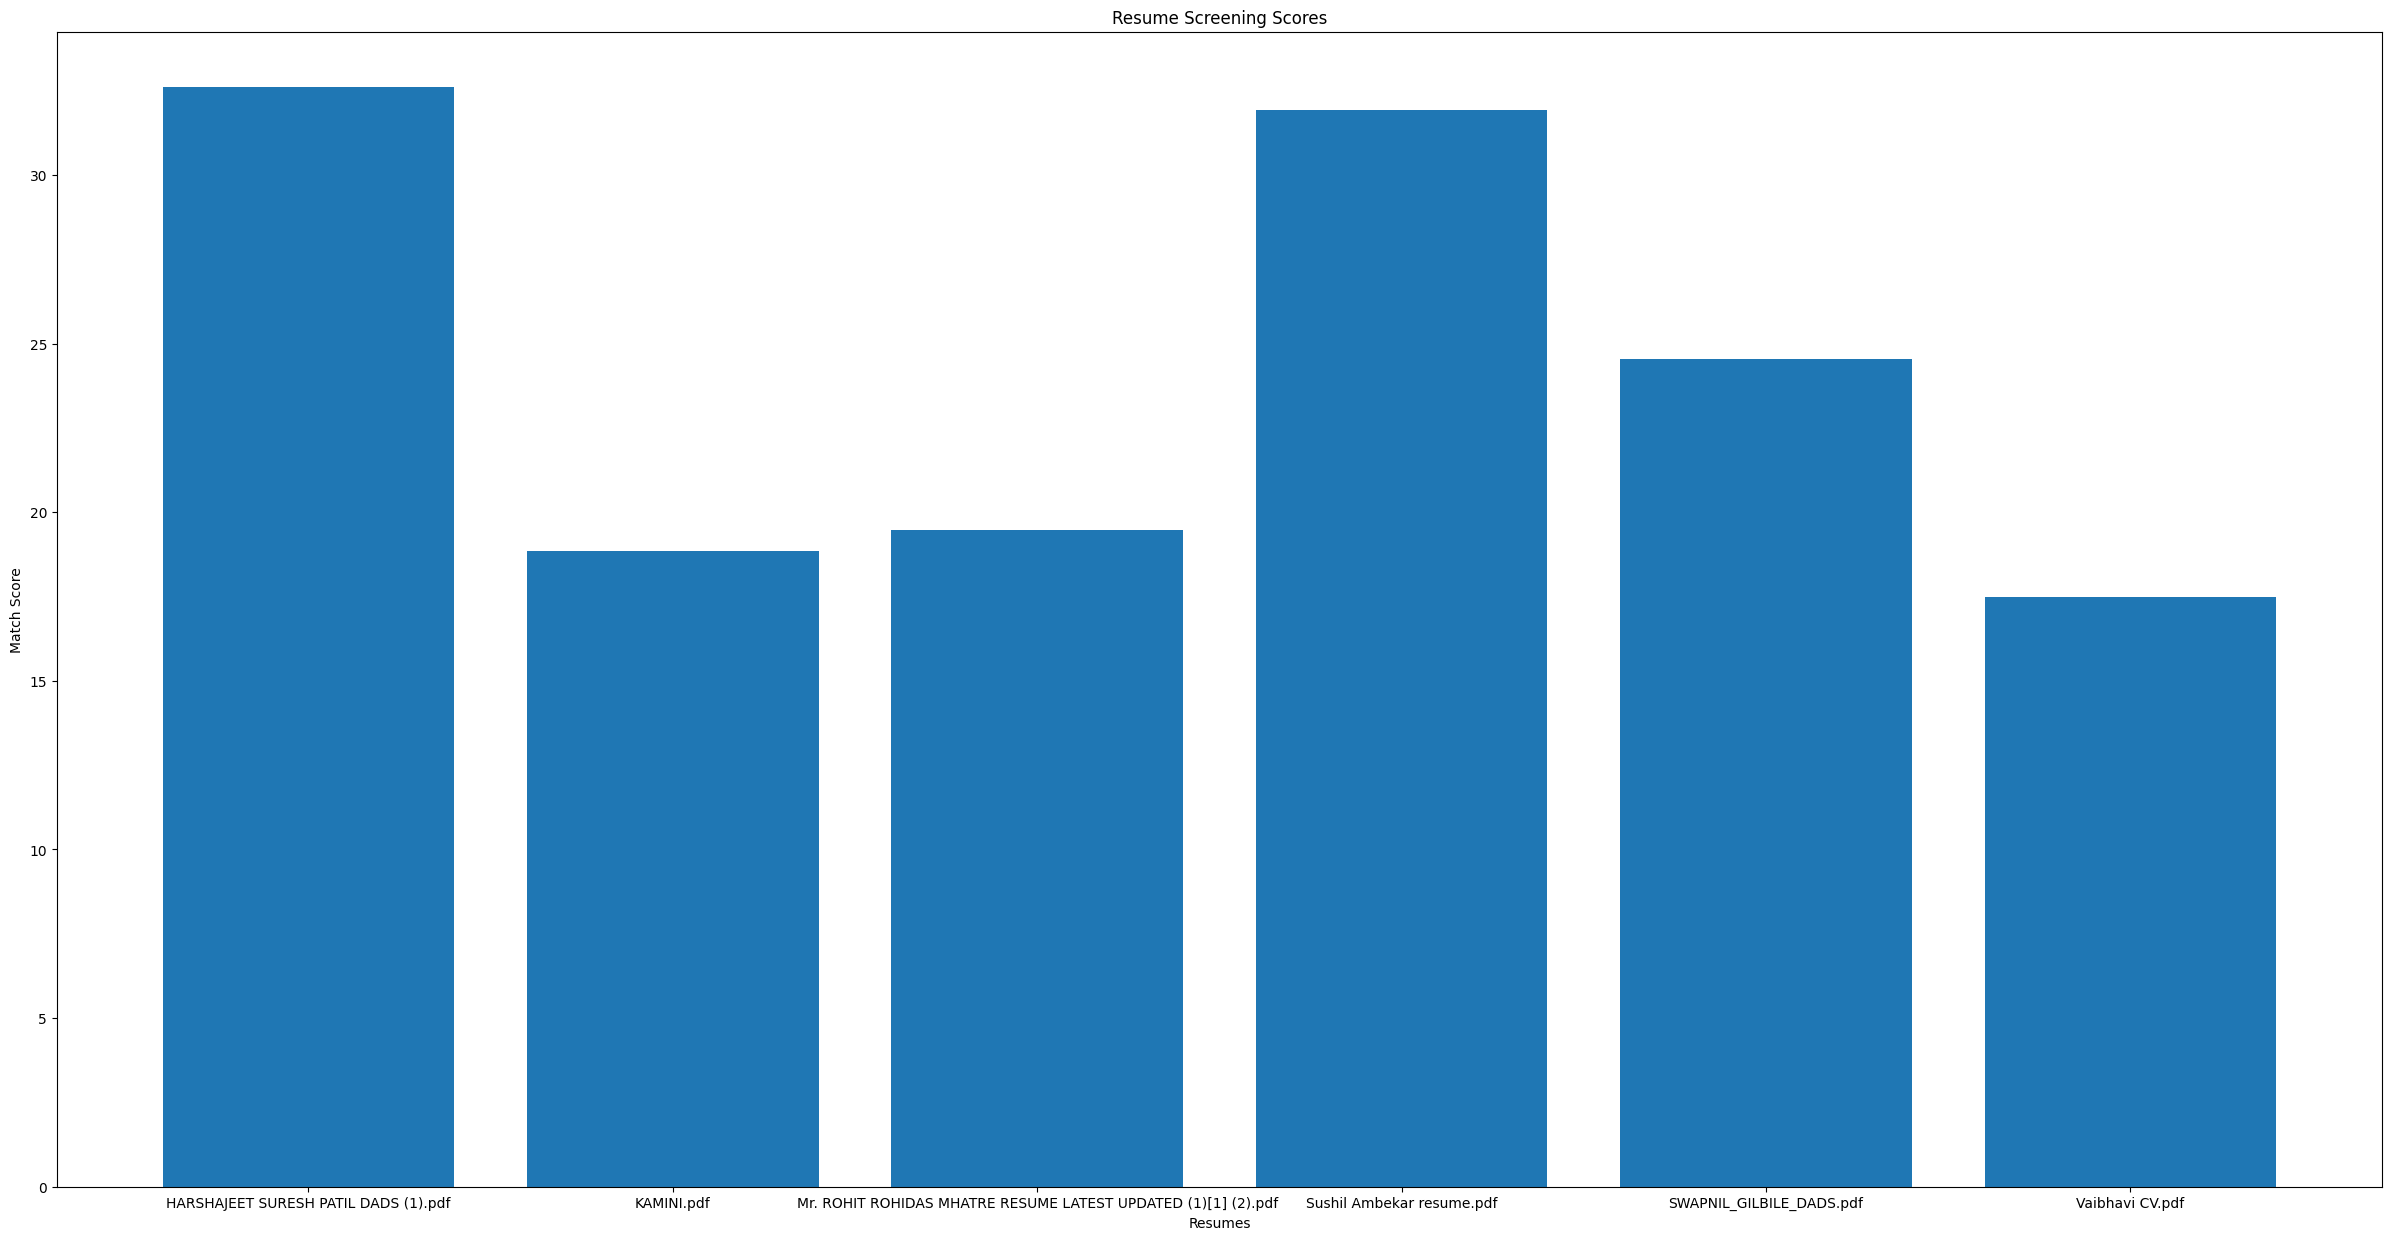

In [41]:
import matplotlib.pyplot as plt

names = list(scores.keys())

values = list(scores.values())

plt.figure(figsize=(30,15))

plt.bar(names, values)

plt.xlabel("Resumes")

plt.ylabel("Match Score")

plt.title("Resume Screening Scores")

plt.show()